# Dataset description
## Forest fires by year

**Source**: Global Nature Watch

**Download**: [Link](https://globalnaturewatch.org/dashboards/country/COL/?category=fires&firesAlerts=eyJpbnRlcmFjdGlvbiI6e319&gladAlerts=eyJpbnRlcmFjdGlvbiI6e319&lang=es_MX&location=WyJjb3VudHJ5IiwiQ09MIl0%3D&mainMap=eyJzaG93QW5hbHlzaXMiOnRydWUsImhpZGVMZWdlbmQiOmZhbHNlfQ%3D%3D&map=eyIwIjoiZSIsIjEiOiJ5IiwiMiI6IkoiLCIzIjoiaiIsIjQiOiJaIiwiNSI6IlciLCI2IjoiNSIsIjciOiIwIiwiOCI6IloiLCI5IjoiWCIsIjEwIjoiSSIsIjExIjoiaSIsIjEyIjoiTyIsIjEzIjoibiIsIjE0IjoicyIsIjE1IjoiaSIsIjE2IjoiYiIsIjE3IjoiRyIsIjE4IjoiRiIsIjE5IjoiMCIsIjIwIjoiSSIsIjIxIjoiaiIsIjIyIjoibyIsIjIzIjoidCIsIjI0IjoiTiIsIjI1IjoiUyIsIjI2IjoiNCIsIjI3IjoiNCIsIjI4IjoiTiIsIjI5IjoiRCIsIjMwIjoiSSIsIjMxIjoiMCIsIjMyIjoiTiIsIjMzIjoiaiIsIjM0IjoiSSIsIjM1IjoiMSIsIjM2IjoiTiIsIjM3IjoiRCIsIjM4IjoiUSIsIjM5IjoieSIsImNhbkJvdW5kIjp0cnVlfQ%3D%3D)

# Code
## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [2]:
path = "./data/viirs_fire_alerts__count.csv"

cols = [
    "alert__year",
    "alert__week",
    "alert__count"
]

df = pd.read_csv(path, encoding="utf-8", usecols=cols)

## CLean data

In [3]:
weeks_35 = df[
    (df["alert__week"].isin(list(range(1,36))))
]

only_august = df[
    (df["alert__week"].isin(list(range(30,36))))
]

by_year = (weeks_35
           .groupby("alert__year")
           .sum()
           .reset_index()
)[["alert__year", "alert__count"]]

by_year_august = (only_august
           .groupby("alert__year")
           .sum()
           .reset_index()
)[["alert__year", "alert__count"]]

## Plot

In [9]:
def plot(df, thousands):
    background = "#F4F1EA"
    blue = "#4a90e2"
    gray = "#D3D3D3"
    color = [blue]

    fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
    fig.patch.set_facecolor(background)
    ax.patch.set_facecolor(background)

    if thousands:
        t_2026 = df[df["alert__year"].eq(2026)][["alert__count"]].values[0]

        color = [blue if x <= t_2026 else gray for x in df["alert__count"]] 

        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

    plt.bar(df["alert__year"], df["alert__count"], color=color)

    plt.xticks(df["alert__year"])

    plt.ylabel("Alerts", labelpad=10, fontsize=10, y=0.9)
    plt.xlabel("Year", labelpad=10, fontsize=10)

    for side in ["top", "bottom", "left", "right"]:
        plt.gca().spines[side].set_visible(False)

    for axis in ["y", "x"]:
        plt.tick_params(axis=axis, length=0)

    plt.show()

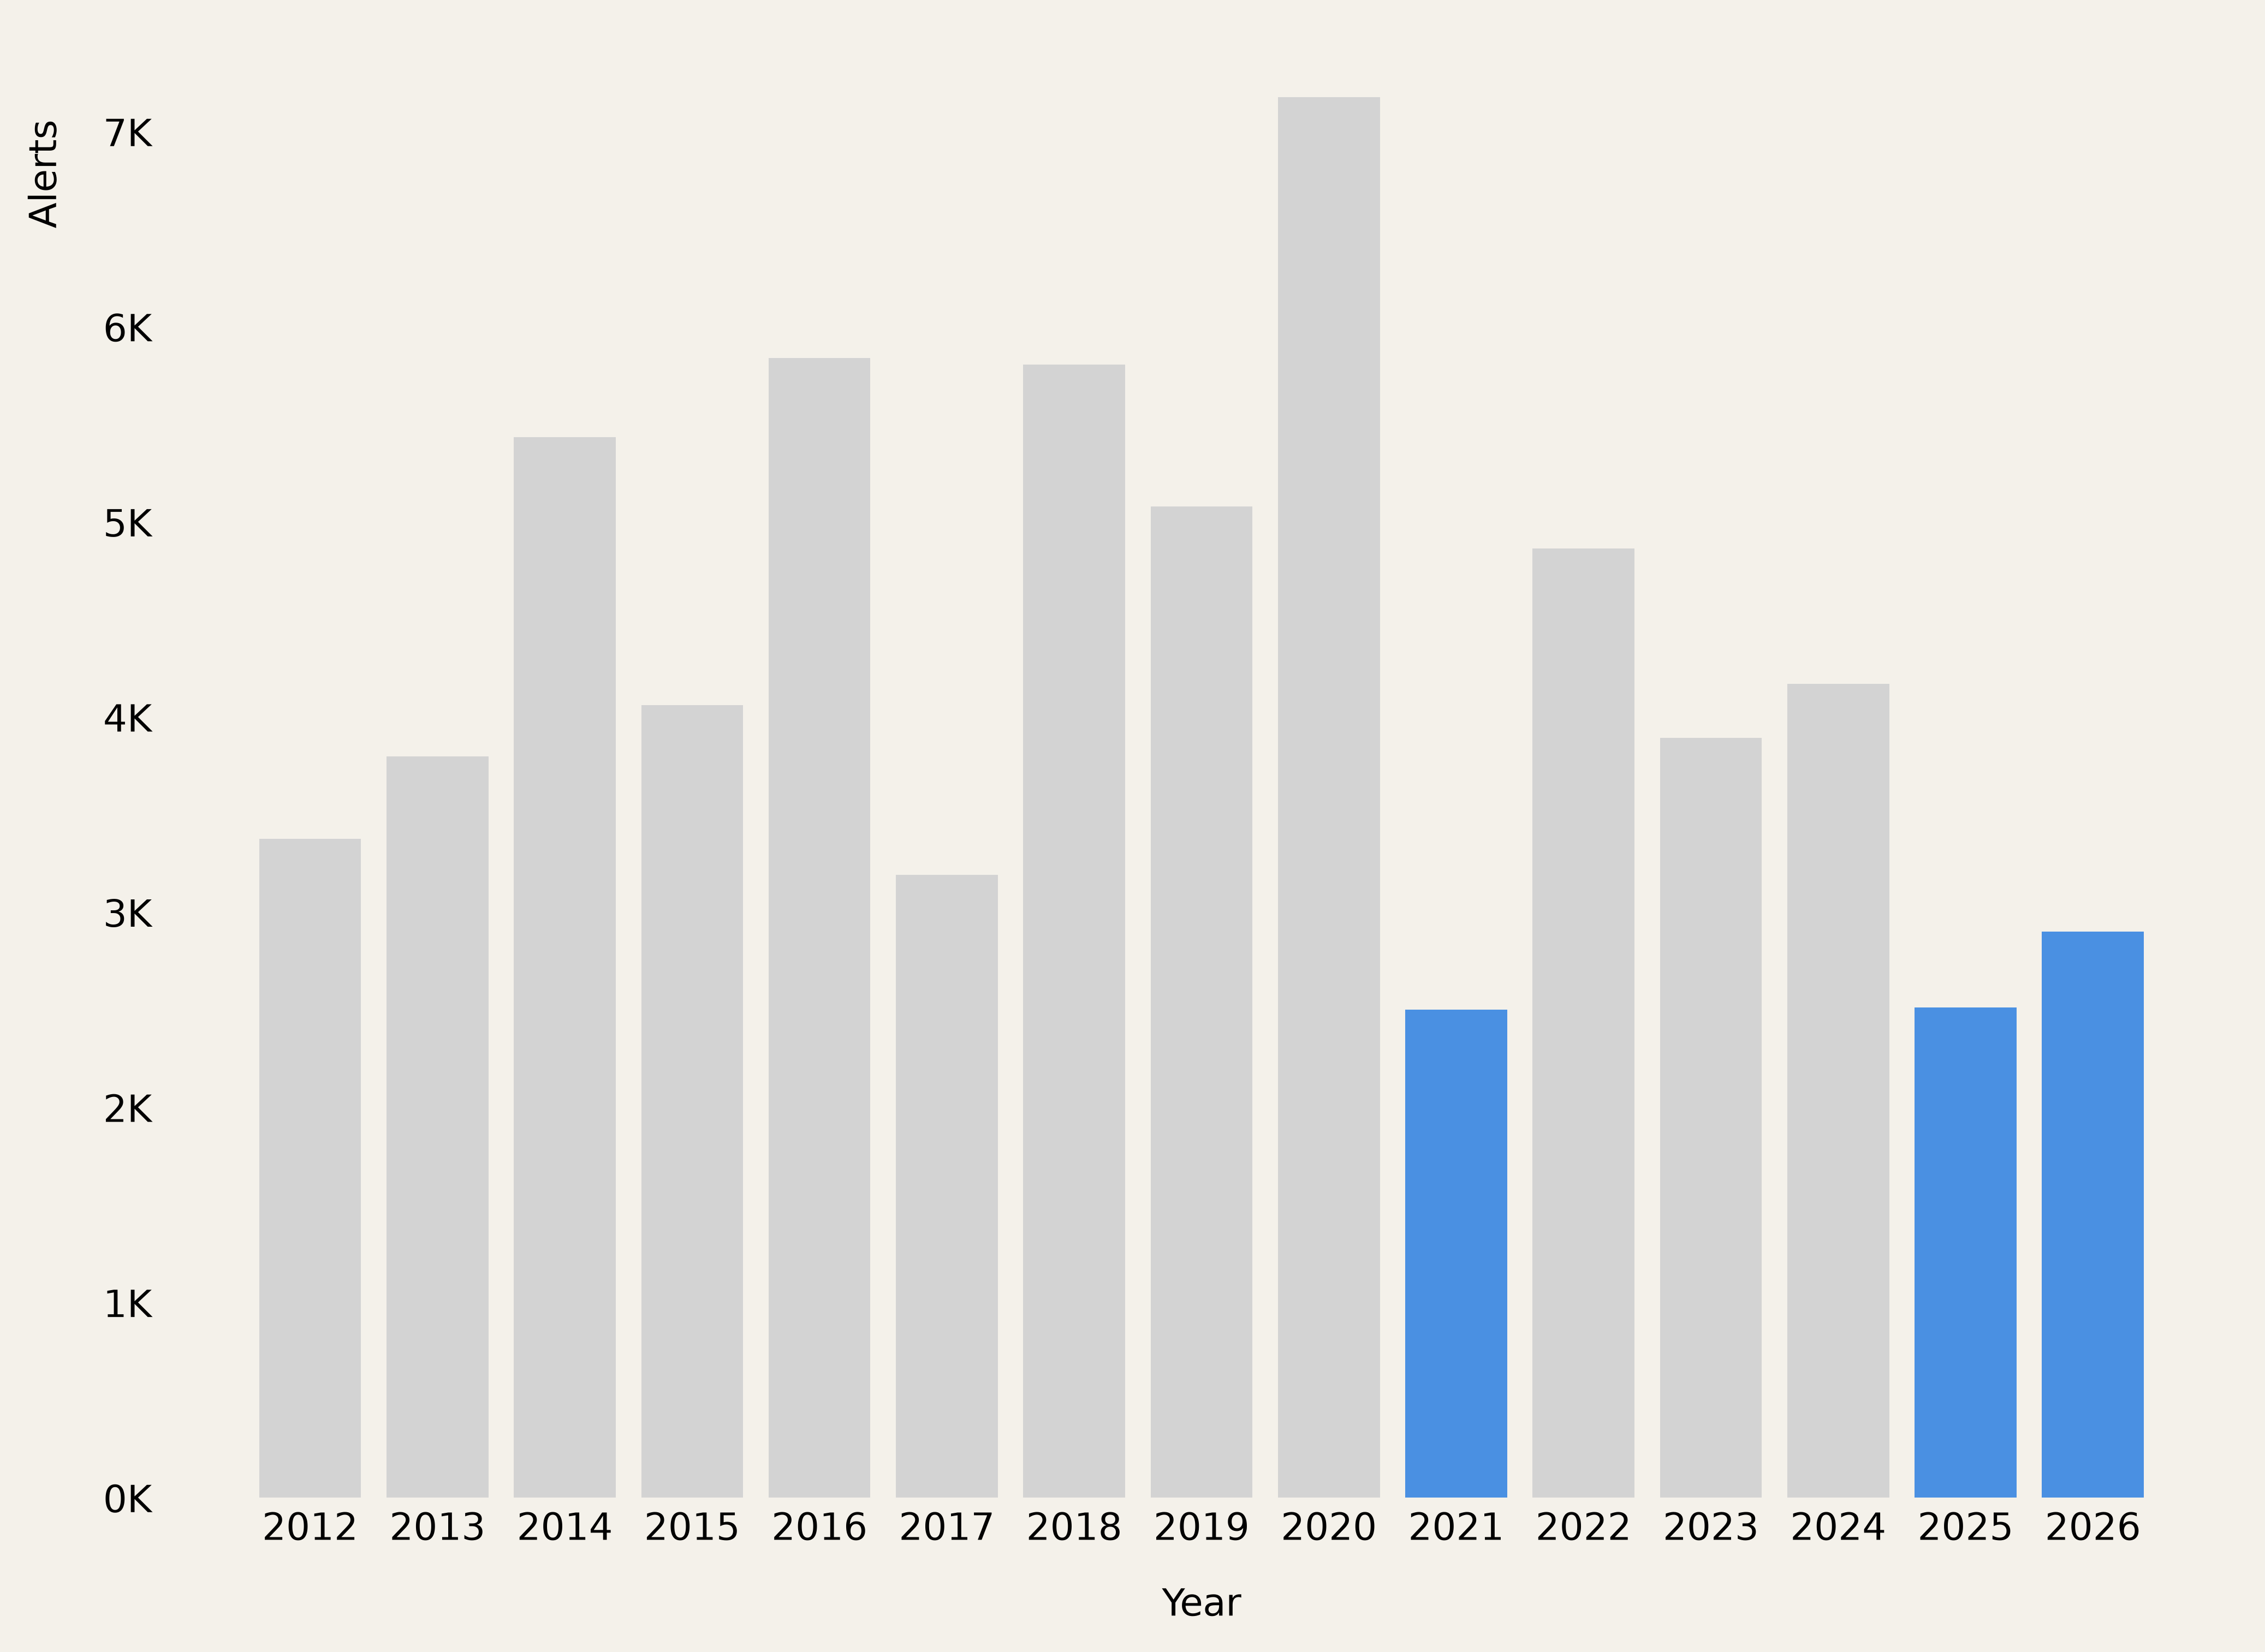

In [10]:
plot(by_year, True)

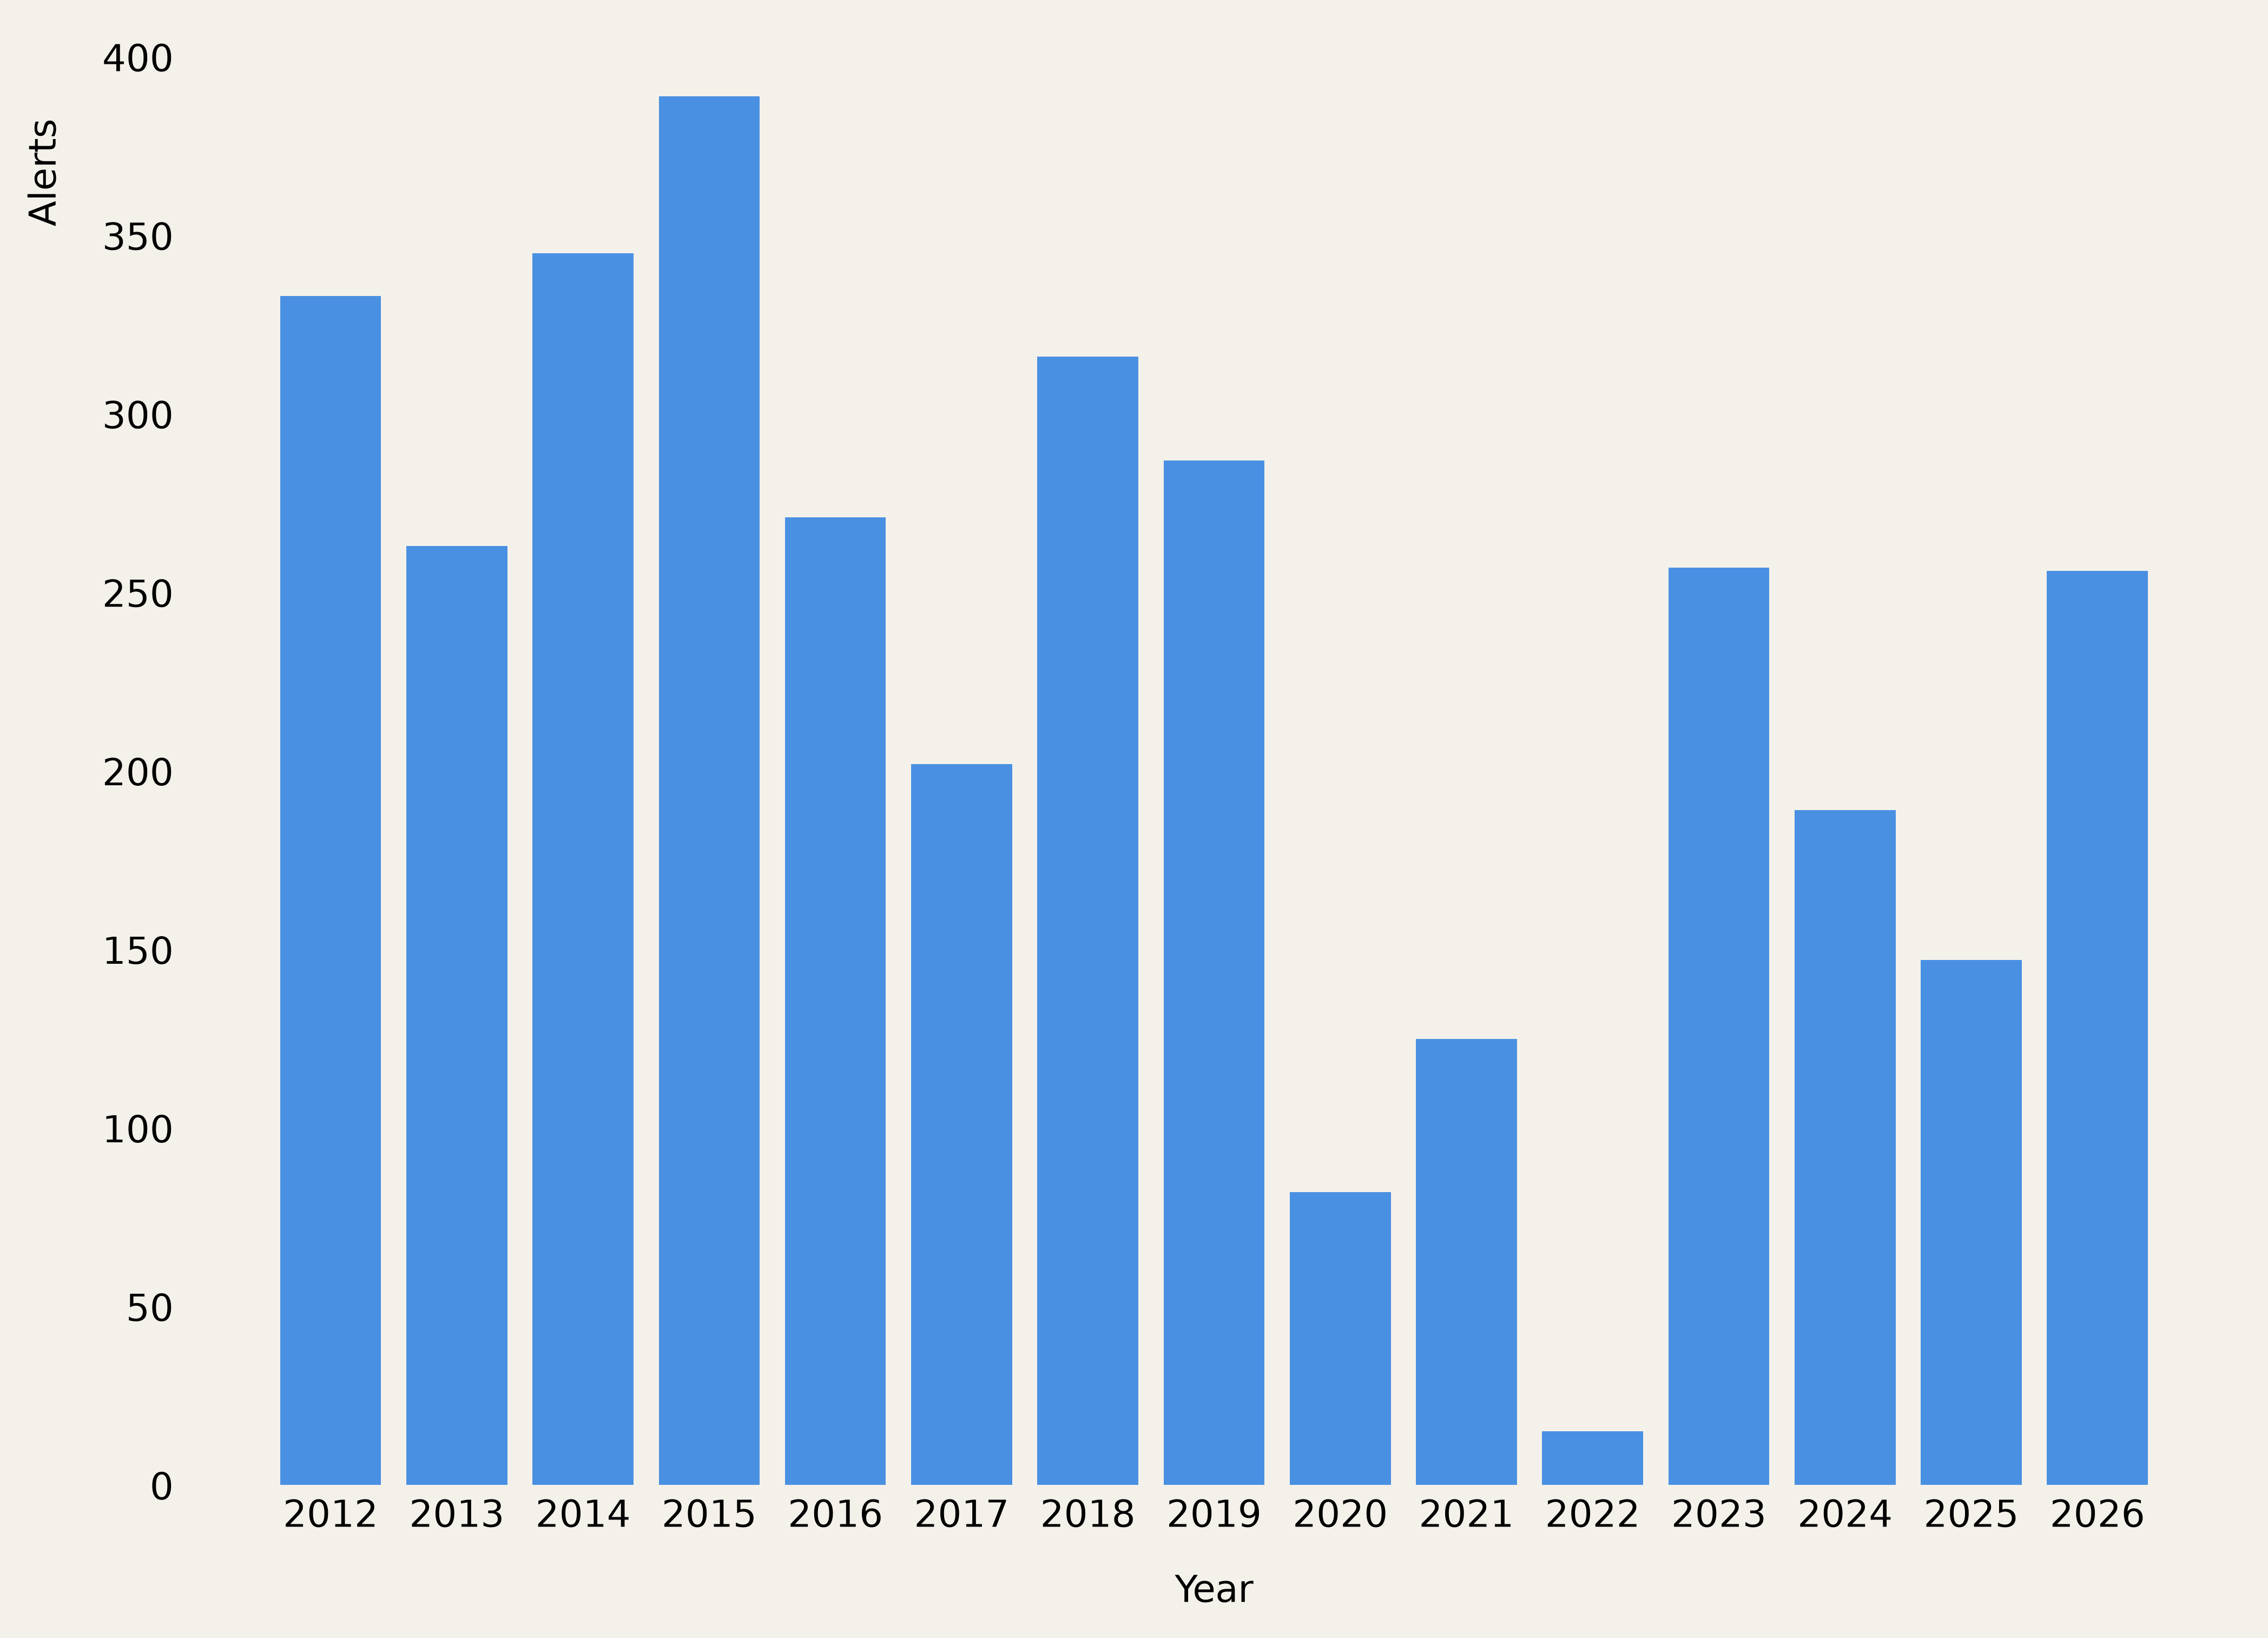

In [8]:
plot(by_year_august, False)